# Import Stackup
This example shows how to import stackup file.

## Import the required packages

In [1]:
import json
from pathlib import Path
import tempfile

from IPython.display import display
from ansys.aedt.core.downloads import download_file
import pandas as pd

from pyedb import Edb

AEDT_VERSION = "2024.2"
NG_MODE = False


C:\Users\ansys\AppData\Local\Temp\ipykernel_9400\2431567430.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Download the example PCB data.

In [2]:
temp_folder = tempfile.TemporaryDirectory(suffix=".ansys")
file_edb = download_file(source="edb/ANSYS-HSD_V1.aedb", destination=temp_folder.name)

## Load example layout.

In [3]:
edbapp = Edb(file_edb, edbversion=AEDT_VERSION)

PyAEDT INFO: Logger is initialized in EDB.


PyAEDT INFO: legacy v0.37.0


PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


PyAEDT INFO: Database ANSYS-HSD_V1.aedb Opened in 2024.2


PyAEDT INFO: Cell main Opened


PyAEDT INFO: Builder was initialized.


PyAEDT INFO: EDB initialized.


## Review original stackup definition

Get original stackup definition in a dictionary. Alternatively, stackup definition can be exported in a json file by
edbapp.configuration.export()

In [4]:
data_cfg = edbapp.configuration.get_data_from_db(stackup=True)

PyAEDT INFO: Getting data from layout database.


In [5]:
df = pd.DataFrame(data=data_cfg["stackup"]["layers"])
display(df)

,name,type,material,fill_material,thickness,color,etching,roughness
0,1_Top,signal,copper,Solder Resist,0.035mm,"[255, 0, 0]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
1,DE1,dielectric,Megtron4,,0.1mm,"[128, 128, 128]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
2,Inner1(GND1),signal,copper,Megtron4_2,0.017mm,"[128, 128, 0]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
3,DE2,dielectric,Megtron4_2,,0.088mm,"[128, 128, 128]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
4,Inner2(PWR1),signal,copper,Megtron4_2,0.017mm,"[112, 219, 250]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
5,DE3,dielectric,Megtron4,,0.1mm,"[128, 128, 128]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
6,Inner3(Sig1),signal,copper,Megtron4_3,0.017mm,"[255, 0, 255]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
7,Megtron4-1mm,dielectric,Megtron4_3,,1mm,"[128, 128, 128]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
8,Inner4(Sig2),signal,copper,Megtron4_3,0.017mm,"[128, 0, 128]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
9,DE5,dielectric,Megtron4,,0.1mm,"[128, 128, 128]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."


## Modify stackup

Modify top layer thickness

In [6]:
data_cfg["stackup"]["layers"][0]["thickness"] = 0.00005

Add a solder mask layer

In [7]:
data_cfg["stackup"]["layers"].insert(
    0, {"name": "soler_mask", "type": "dielectric", "material": "Megtron4", "fill_material": "", "thickness": 0.00002}
)

Review modified stackup

In [8]:
df = pd.DataFrame(data=data_cfg["stackup"]["layers"])
display(df.head(3))

,name,type,material,fill_material,thickness,color,etching,roughness
0,soler_mask,dielectric,Megtron4,,0.00002,NaN,NaN,NaN
1,1_Top,signal,copper,Solder Resist,0.00005,"[255, 0, 0]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."
2,DE1,dielectric,Megtron4,,0.1mm,"[128, 128, 128]","{'factor': '0', 'enabled': False, 'etch_power_...","{'top': {'model': 'huray', 'nodule_radius': '0..."


Write stackup definition into a json file

In [9]:
file_cfg = Path(temp_folder.name) / "edb_configuration.json"
with open(file_cfg, "w") as f:
    json.dump(data_cfg, f, indent=4, ensure_ascii=False)

## Load stackup from json configuration file

In [10]:
edbapp.configuration.load(file_cfg, apply_file=True)

Plot stackup

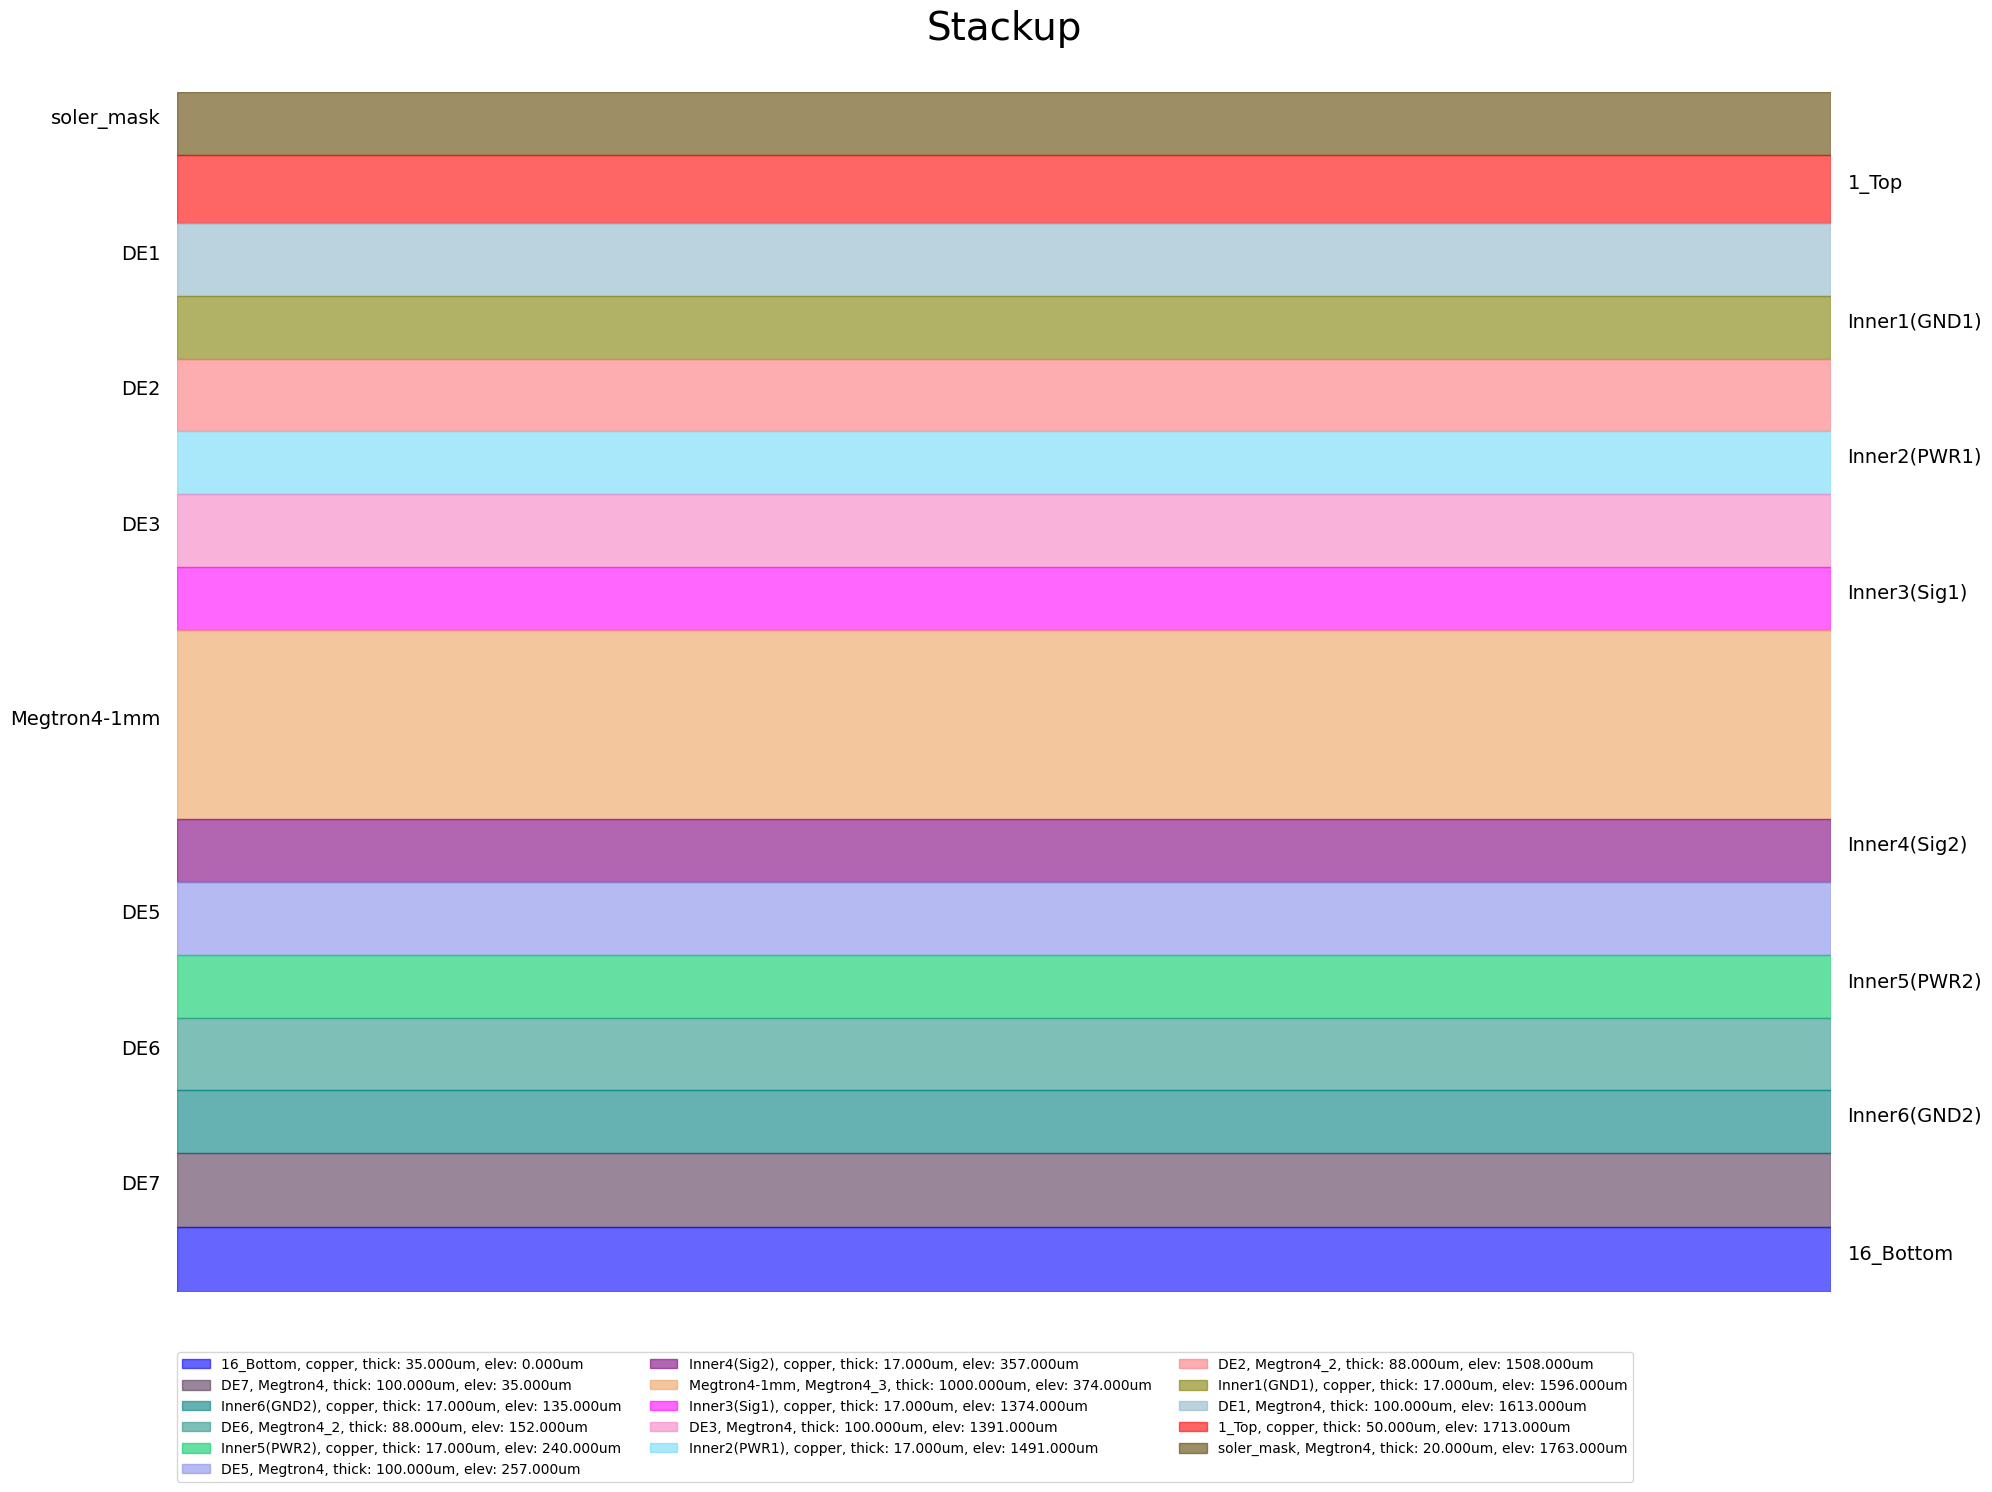

<module 'matplotlib.pyplot' from 'C:\\actions-runner\\_work\\pyaedt-examples\\pyaedt-examples\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [11]:
edbapp.stackup.plot()

Check top layer thickness

In [12]:
edbapp.stackup["1_Top"].thickness

5e-05

## Save and close Edb
The temporary folder will be deleted once the execution of this script is finished. Replace **edbapp.save()** with
**edbapp.save_as("C:/example.aedb")** to keep the example project.

In [13]:
edbapp.save()
edbapp.close()

True